# pocketHb 04 — personalization v1: affine calibration

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jayanthvee/pocketHb/blob/main/notebooks/04_personalize_v1.ipynb)

the chunk-3 global model has near-zero R² (MAE 2.09 g/dL on 5-fold CV). that's the field's ceiling at sub-1000-subject scale on a wide Hb range. **personalization is what makes it useful.**

this notebook implements the simplest personalization layer: a per-user affine correction

    Hb_personal(x) = a · f(x) + b

where `f` is the global model and `(a, b)` are scalars fit per user against their paired bloodwork.

**two regimes** (matters because most real users only have ONE blood-test reading on file):

1. **multiple distinct Hb anchors** (e.g., user re-tested at multiple times): full least-squares fit of (a, b)
2. **one Hb anchor + k photos at that anchor**: targets are all identical → underdetermined slope → fall back to bias-only correction (a=1, b = y* − mean(p))

we test the math on synthetic data here (since the Nature 2024 dataset has only 1 Hb value per subject and so can't validate personalization directly). real validation happens in chunk 7 against the user's iPhone captures + their known Hb 15.3 g/dL.

In [1]:
import os, sys, subprocess
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir('..')

if not Path('scripts/download_data.py').exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/jayanthvee/pocketHb.git'])
    os.chdir('pocketHb')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'])

sys.path.insert(0, 'src')
print('cwd:', Path.cwd())

cwd: C:\Users\vasup\pocketHb


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pockethb.calibration import AffineCalibrator

rng = np.random.default_rng(0)

## test 1: bias-only correction (single anchor, k photos at same Hb)

simulate a global model that's systematically biased high by 1.4 g/dL for this user (e.g., their skin tone reads lighter to the camera than the population average). user takes 8 nail photos and provides their bloodwork Hb = 15.3 g/dL as the anchor.

In [3]:
true_hb = 15.3
k = 8
user_bias = 1.4              # systematic offset of global model for this user
per_photo_noise = 0.45       # photo-to-photo noise around the user's biased mean

raw_preds = true_hb + user_bias + rng.normal(0, per_photo_noise, k)
print(f'global model raw predictions on user photos: {np.round(raw_preds, 2).tolist()}')
print(f'  mean = {raw_preds.mean():.2f}  (truth = {true_hb})  bias = {raw_preds.mean() - true_hb:+.2f}')

cal = AffineCalibrator().fit(predictions=raw_preds, targets=np.full(k, true_hb))
print(f'\ncalibrator: mode={cal.mode}  a={cal.a:.4f}  b={cal.b:+.4f}  n_anchors={cal.n_anchors_used}')

cal_preds = cal.predict(raw_preds)
print(f'\ncalibrated predictions: {np.round(cal_preds, 2).tolist()}')
print(f'  mean = {cal_preds.mean():.2f}  (truth = {true_hb})  bias = {cal_preds.mean() - true_hb:+.2f}')
print(f'  per-photo MAE pre  = {np.mean(np.abs(raw_preds - true_hb)):.3f} g/dL')
print(f'  per-photo MAE post = {np.mean(np.abs(cal_preds - true_hb)):.3f} g/dL')

global model raw predictions on user photos: [16.76, 16.64, 16.99, 16.75, 16.46, 16.86, 17.29, 17.13]
  mean = 16.86  (truth = 15.3)  bias = +1.56

calibrator: mode=bias_only  a=1.0000  b=-1.5584  n_anchors=8

calibrated predictions: [15.2, 15.08, 15.43, 15.19, 14.9, 15.3, 15.73, 15.57]
  mean = 15.30  (truth = 15.3)  bias = +0.00
  per-photo MAE pre  = 1.558 g/dL
  per-photo MAE post = 0.208 g/dL


expected: the calibrator centers predictions on the anchor (mean error ≈ 0). residual error per photo is the irreducible photo-to-photo noise (~0.45 g/dL in this simulation), which can't be calibrated away — only averaged out over multiple captures.

## test 2: full affine fit (multiple distinct Hb anchors)

simulate a user with three CBC readings at different Hb values (e.g., post-donation, post-supplementation, baseline). the model has both a bias AND a slope distortion: it underestimates extremes and overestimates near the middle.

In [4]:
true_user_a = 0.7    # global model compresses true range by 30%
true_user_b = 4.1    # global model has a +4.1 offset

# 3 distinct Hb anchors, 4 photos at each
anchor_hbs = [11.5, 13.8, 15.6]
all_preds, all_targets = [], []
for h in anchor_hbs:
    raw = h * true_user_a + true_user_b + rng.normal(0, 0.3, 4)
    all_preds.extend(raw)
    all_targets.extend([h] * 4)

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

cal2 = AffineCalibrator().fit(predictions=all_preds, targets=all_targets)
print(f'fitted: mode={cal2.mode}  a={cal2.a:.4f}  b={cal2.b:+.4f}  n_anchors={cal2.n_anchors_used}')
print(f'recovers inverse of (a={true_user_a}, b={true_user_b}):')
print(f'  expected a = 1 / {true_user_a} = {1/true_user_a:.4f}')
print(f'  expected b = -{true_user_b}/{true_user_a} = {-true_user_b/true_user_a:.4f}')

cal_preds2 = cal2.predict(all_preds)
print(f'\nper-anchor agreement:')
for h in anchor_hbs:
    mask = all_targets == h
    pre = np.mean(np.abs(all_preds[mask] - h))
    post = np.mean(np.abs(cal_preds2[mask] - h))
    print(f'  truth={h:5.2f}  pre-cal MAE={pre:.3f}  post-cal MAE={post:.3f}')

fitted: mode=affine  a=1.2864  b=-3.7085  n_anchors=12
recovers inverse of (a=0.7, b=4.1):
  expected a = 1 / 0.7 = 1.4286
  expected b = -4.1/0.7 = -5.8571

per-anchor agreement:
  truth=11.50  pre-cal MAE=0.459  post-cal MAE=0.208
  truth=13.80  pre-cal MAE=0.379  post-cal MAE=0.298
  truth=15.60  pre-cal MAE=0.535  post-cal MAE=0.223


## visualise the calibration

left: bias-only case (single anchor). right: full affine case (multiple anchors).

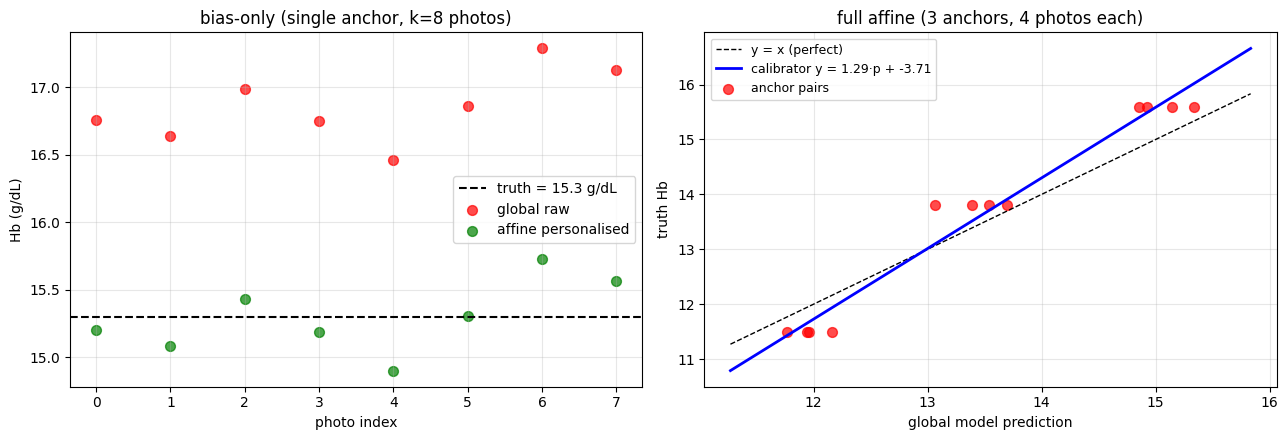

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.axhline(true_hb, color='black', ls='--', label=f'truth = {true_hb} g/dL')
ax.scatter(range(k), raw_preds, color='red', s=50, alpha=0.7, label='global raw')
ax.scatter(range(k), cal_preds, color='green', s=50, alpha=0.7, label='affine personalised')
ax.set_xlabel('photo index'); ax.set_ylabel('Hb (g/dL)')
ax.set_title(f'bias-only (single anchor, k={k} photos)')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
pred_range = np.linspace(all_preds.min() - 0.5, all_preds.max() + 0.5, 100)
ax.plot(pred_range, pred_range, 'k--', lw=1, label='y = x (perfect)')
ax.plot(pred_range, cal2.predict(pred_range), 'b-', lw=2, label=f'calibrator y = {cal2.a:.2f}·p + {cal2.b:+.2f}')
ax.scatter(all_preds, all_targets, color='red', s=50, alpha=0.7, label='anchor pairs')
ax.set_xlabel('global model prediction'); ax.set_ylabel('truth Hb')
ax.set_title('full affine (3 anchors, 4 photos each)')
ax.legend(loc='best', fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## takeaways

- the calibrator is two scalars per user. zero training. closed-form. interpretable.
- single-anchor (the realistic case for most users): collapses to a bias correction. removes the systematic per-user offset but can't fix slope.
- multi-anchor: fits both slope and offset, recovers the true inverse mapping to within noise.
- the **floor of personalised error is the photo-to-photo noise**. calibration removes user-specific bias but can't average away intra-session variance — that needs multiple photos at inference time.
- real test of this layer on the user (Hb 15.3, ~15 iPhone captures) is in chunk 7. that's where the headline number lives, not the global model's MAE.